# Import

In [38]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Plot Accuracy

In [19]:
mode = "visual" #  "image" or "text_only"
with open(f"evaluation_results_with_{mode}.json", "r") as f:
    evaluation_data = json.load(f)

In [20]:
# Build DataFrames from the new evaluation_results.json structure
eval_rows = []
group_rows = []

for level_str, stats in evaluation_data.items():
    level = int(level_str)
    eval_rows.append({
        "level": level,
        "correct": stats.get("correct", 0),
        "total": stats.get("total", 0),
        "acc": stats.get("acc", 0.0),
    })

    by_group = stats.get("by_rel_group", {}) or {}
    for g_name, g_stats in by_group.items():
        group_rows.append({
            "level": level,
            "rel_group": g_name,
            "correct": g_stats.get("correct", 0),
            "total": g_stats.get("total", 0),
            "acc": g_stats.get("acc", 0.0),
        })

eval_df = pd.DataFrame(eval_rows).sort_values("level").reset_index(drop=True)
group_df = pd.DataFrame(group_rows).sort_values(["level", "rel_group"]).reset_index(drop=True)

# Labels for plotting
eval_df["level_label"] = eval_df["level"].apply(lambda k: f"level {k}")
if not group_df.empty:
    group_df["level_label"] = group_df["level"].apply(lambda k: f"level {k}")

eval_df.head()

,level,correct,total,acc,level_label
0,0,89,160,55.625000,level 0
1,1,102,160,63.750000,level 1
2,2,236,296,79.729730,level 2
3,3,691,920,75.108696,level 3
4,4,1307,1836,71.187364,level 4


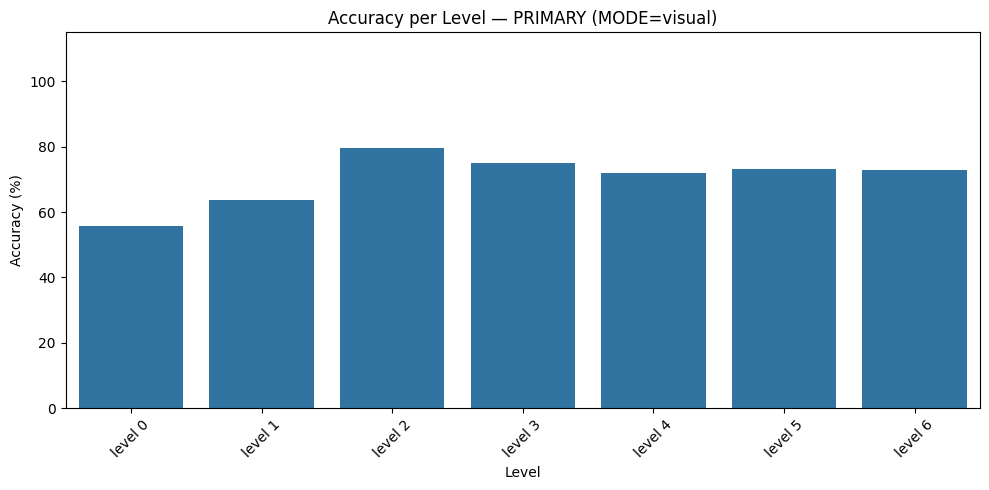

In [21]:
# Plot 2a: PRIMARY
primary_df = group_df[group_df["rel_group"] == "PRIMARY"]

if not primary_df.empty:
    plt.figure(figsize=(10, 5))
    ax_p = sns.barplot(
        data=primary_df,
        x="level_label",
        y="acc"
    )

    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level — PRIMARY (MODE={mode})")
    plt.ylim(0, 115)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"plots/accuracy_primary_{mode}.png")
    plt.show()
else:
    print("No PRIMARY data found")


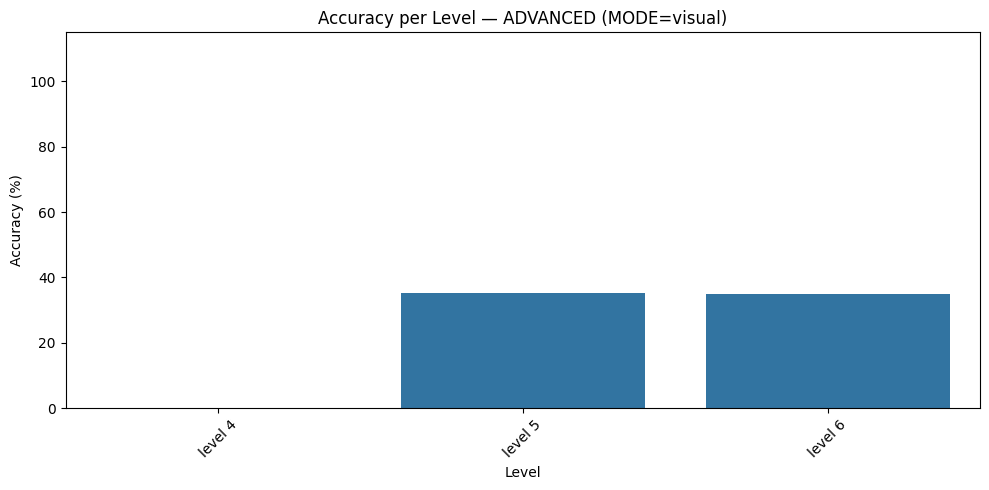

In [22]:
# Plot 2b: ADVANCED
advanced_df = group_df[group_df["rel_group"] == "ADVANCED"]

if not advanced_df.empty:
    plt.figure(figsize=(10, 5))
    ax_a = sns.barplot(
        data=advanced_df,
        x="level_label",
        y="acc"
    )


    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level — ADVANCED (MODE={mode})")
    plt.ylim(0, 115)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"plots/accuracy_advanced_{mode}.png")
    plt.show()
else:
    print("No ADVANCED data found")


In [23]:
# Optional: view per-group table
group_df

,level,rel_group,correct,total,acc,level_label
0,0,PRIMARY,89,160,55.625000,level 0
1,1,PRIMARY,102,160,63.750000,level 1
2,2,PRIMARY,236,296,79.729730,level 2
3,3,PRIMARY,691,920,75.108696,level 3
4,4,ADVANCED,0,16,0.000000,level 4
5,4,PRIMARY,1307,1820,71.813187,level 4
6,5,ADVANCED,90,256,35.156250,level 5
7,5,PRIMARY,1278,1744,73.279817,level 5
8,6,ADVANCED,80,230,34.782609,level 6
9,6,PRIMARY,1292,1770,72.994350,level 6


# Reading Logs

In [32]:
mode = "visual"
logs_df = pd.read_csv(f"./model_calls_log_with_{mode}.csv")
print(logs_df.head(5))
# print(list(logs_df[(logs_df["Model_Prediction"] == "no") & (logs_df["Ground_Truth"] == "yes")]['Prompt']))
mask = logs_df["Model_Prediction"].str.strip().str.lower() != logs_df["Ground_Truth"].str.strip().str.lower()
print(len(logs_df[mask]))

             Timestamp  Level  \
0  2025-12-30 15:36:38      0   
1  2025-12-30 15:36:39      0   
2  2025-12-30 15:36:40      0   
3  2025-12-30 15:36:41      0   
4  2025-12-30 15:36:41      0   

                                          Image_Path Rel_Group Rel_Type  \
0  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    above   
1  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    below   
2  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    below   
3  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY    above   
4  /home/kkarthikeyan/deep-learning/DeepLearningP...   PRIMARY  left_of   

                                              Prompt Completion  Confidence  \
0  [INST] <image>\nUse the spatial layout in the ...        Yes    0.542863   
1  [INST] <image>\nUse the spatial layout in the ...        Yes    0.577495   
2  [INST] <image>\nUse the spatial layout in the ...        Yes    0.709019   
3  [INST] <image>\nUse the spatial

In [33]:
import textwrap

df_bad = logs_df[mask].reset_index(drop=True)

def wrap(s, width=110):
    return textwrap.fill("" if pd.isna(s) else str(s), width=width)

for i, row in enumerate(df_bad.itertuples(index=False), start=1):
    print("\n" + "=" * 120)
    gt = getattr(row, "Ground_Truth", "")
    pred = getattr(row, "Model_Prediction", "")
    conf = getattr(row, "Confidence", "")
    print(f"[{i}] GT={gt}  PRED={pred}  CONF={conf}")
    print("-" * 120)

    prompt = getattr(row, "Prompt", "")
    completion = getattr(row, "Completion", "")

    print("PROMPT:\n" + wrap(prompt))
    print("\nCOMPLETION:\n" + wrap(completion))


[1] GT=no  PRED=yes  CONF=0.5774952382230393
------------------------------------------------------------------------------------------------------------------------
PROMPT:
[INST] <image> Use the spatial layout in the image to answer the following relational reasoning question with
either "yes" or "no". Is the yellow square below the pink star? [/INST] MODEL: Yes

COMPLETION:
Yes

[2] GT=no  PRED=yes  CONF=0.6150879504705026
------------------------------------------------------------------------------------------------------------------------
PROMPT:
[INST] <image> Use the spatial layout in the image to answer the following relational reasoning question with
either "yes" or "no". Is the pink star above the yellow square? [/INST] MODEL: Yes

COMPLETION:
Yes

[3] GT=yes  PRED=no  CONF=0.5039063910016547
------------------------------------------------------------------------------------------------------------------------
PROMPT:
[INST] <image> Use the spatial layout in the image to a

In [34]:
logs_df["Model_Prediction"].value_counts(dropna=False)

Model_Prediction
yes    5157
no     2215
Name: count, dtype: int64

In [35]:
logs_df["Ground_Truth"].value_counts(dropna=False)

Ground_Truth
yes    3686
no     3686
Name: count, dtype: int64

## Plot Confusion Matrix

In [28]:
def generate_confusion_matrix(csv_file, output_image=f'plots/confusion_matrix_{mode}.png'):
    # 1. Load the data
    df = pd.read_csv(csv_file)

    # 2. Clean and Normalize labels (handling whitespace/case)
    y_true = df['Ground_Truth'].str.strip().str.lower()
    y_pred = df['Model_Prediction'].str.strip().str.lower()

    # 3. Compute Confusion Matrix
    # We explicitly set labels to ensure the order is consistent
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 4. Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Yes', 'Predicted No'], 
                yticklabels=['Actual Yes', 'Actual No'])

    plt.title(f'VLM Relational Reasoning Confusion Matrix (MODE={mode})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # 5. Save and Show
    plt.savefig(output_image, bbox_inches='tight', dpi=300)
    print(f"Confusion matrix saved to {output_image}")
    plt.show()

Confusion matrix saved to plots/confusion_matrix_visual.png


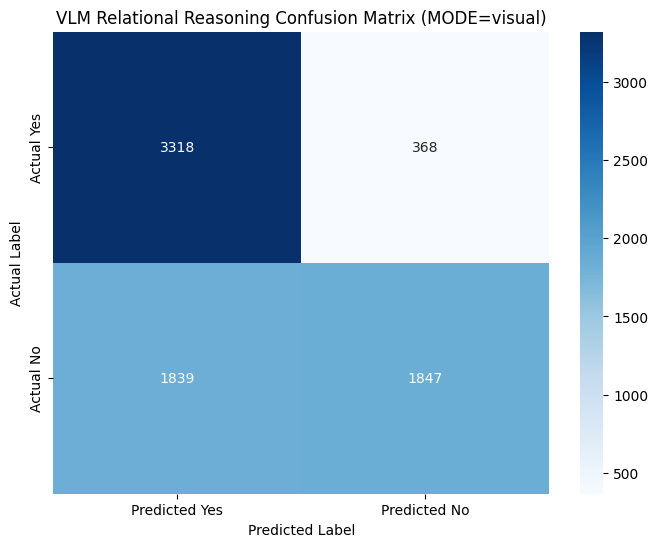

In [29]:
generate_confusion_matrix(f"./model_calls_log_with_{mode}.csv")

In [ ]:
def plot_confusion_matrices_by_rel_type_grid(
    csv_file,
    rel_col="Rel_Type",
    labels=("yes", "no"),
    max_cols=3,
    output_image=None,
):
    # 1. Load and normalize labels
    df = pd.read_csv(csv_file).copy()
    df["_y_true"] = df["Ground_Truth"].astype(str).str.strip().str.lower()
    df["_y_pred"] = df["Model_Prediction"].astype(str).str.strip().str.lower()

    # 2. Build grouped relation type
    # touching + not_touching -> "touching"
    # inside + encapsulates   -> "inside_encapsulates"
    rel_raw = df[rel_col].astype(str).str.strip().str.lower()

    group_map = {
        "touching": "touching",
        "not_touching": "touching",
        "inside": "inside_encapsulates",
        "encapsulates": "inside_encapsulates",
        "overlapping": "overlapping",
        "not_overlapping": "overlapping"
    }

    df["_rel_group"] = rel_raw.map(group_map).fillna(rel_raw)

    # Drop rows that are empty after grouping
    df = df[df["_rel_group"].notna() & (df["_rel_group"] != "")]
    rel_types = sorted(df["_rel_group"].unique())
    n = len(rel_types)
    if n == 0:
        print("No valid relation types found.")
        return

    # 3. Prepare grid
    cols = min(max_cols, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    last_im = None
    for idx, rel in enumerate(rel_types):
        ax = axes_flat[idx]
        sub = df[df["_rel_group"] == rel]
        if sub.empty:
            ax.axis("off")
            continue

        cm = confusion_matrix(sub["_y_true"], sub["_y_pred"], labels=list(labels))

        im = sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[f"Pred {l}" for l in labels],
            yticklabels=[f"Actual {l}" for l in labels],
            cbar=False,
            ax=ax,
        )
        ax.set_title(rel)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        last_im = im

    # Turn off any unused axes
    for j in range(len(rel_types), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"Confusion Matrices by Rel_Type (grouped, MODE={mode})", y=1.02, fontsize=14)
    fig.tight_layout()

    if output_image is None:
        output_image = f"plots/confusion_matrices_by_{rel_col}_{mode}.png"
    os.makedirs(os.path.dirname(output_image), exist_ok=True)
    fig.savefig(output_image, bbox_inches="tight", dpi=300)
    print(f"Saved grouped grid figure to {output_image}")
    plt.show()

Saved grouped grid figure to plots/confusion_matrices_by_rel_type_grouped_grid_visual.png


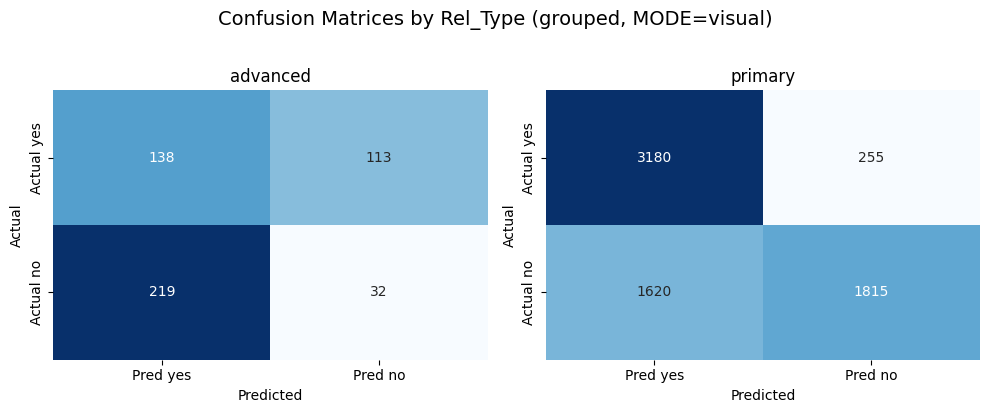

In [50]:
plot_confusion_matrices_by_rel_type_grid(f"./model_calls_log_with_{mode}.csv", rel_col="Rel_Group")

Saved grouped grid figure to plots/confusion_matrices_by_rel_type_grouped_grid_visual.png


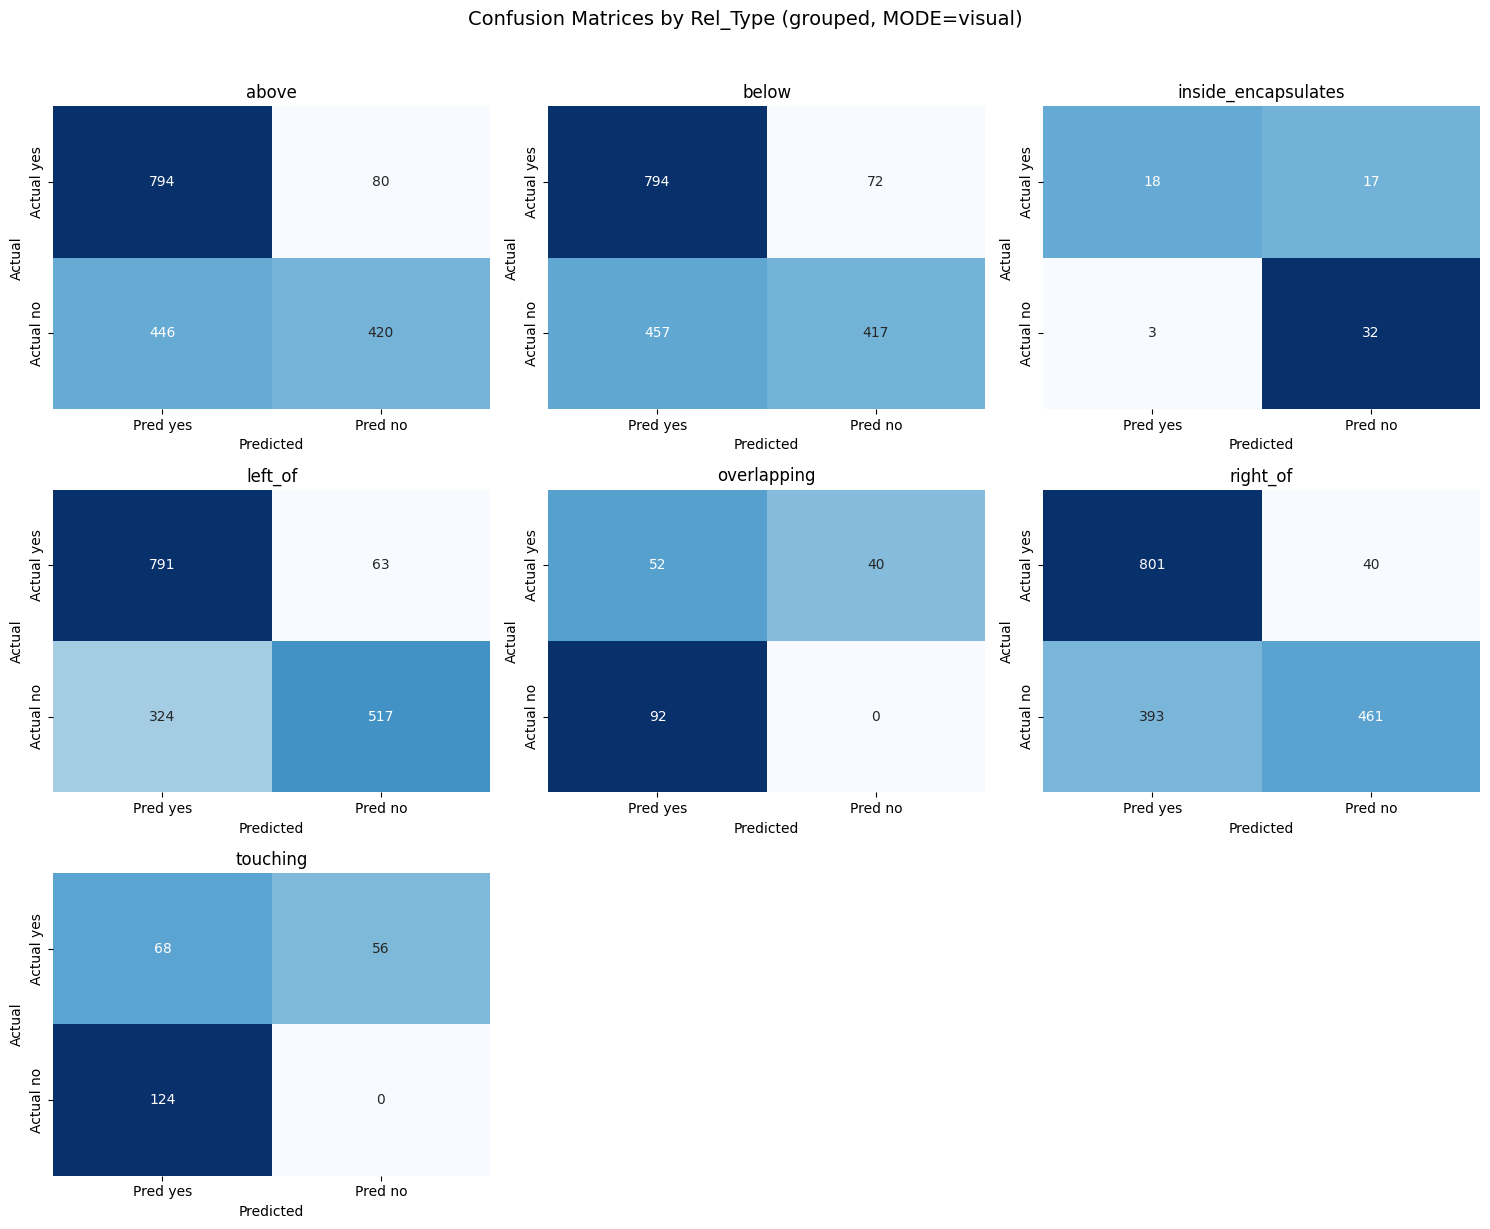

In [51]:
plot_confusion_matrices_by_rel_type_grid(f"./model_calls_log_with_{mode}.csv")